# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [69]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [70]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [71]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [75]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [76]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [77]:
df.Segment.unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [78]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [79]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [80]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [81]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [82]:
query2 = """ 
select
c.customer_id,
c.customer_name,
sum(od.sales) as total_sales
from customers c
join orders o on c.customer_id = o.customer_id
join order_details od on o.order_id = od.order_id
group by c.customer_id, c.customer_name
order by total_sales desc
limit 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,KL-16645,Ken Lonsdale,155927.519
1,SE-20110,Sanjit Engle,134303.818
2,CL-12565,Clay Ludtke,130566.552
3,AB-10105,Adrian Barton,130262.139
4,SC-20095,Sanjit Chand,127281.006
5,SM-20320,Sean Miller,125215.250
6,EH-13765,Edward Hooks,123730.560
7,GT-14710,Greg Tran,118201.200
8,SV-20365,Seth Vernon,114709.500
9,JL-15835,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [83]:
query3 = """
select
p.category,
p.subcategory,
sum(od.profit) as total_profit
from products p
join order_details od on p.product_id = od.product_id
group by p.category, p.subcategory
order by total_profit desc;
"""
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.8249
1,Technology,Accessories,48359.0527
2,Technology,Phones,46936.1861
3,Office Supplies,Paper,36994.5335
4,Office Supplies,Binders,30373.2020
5,Furniture,Chairs,26707.6526
6,Office Supplies,Storage,21408.7032
7,Office Supplies,Appliances,18514.4928
8,Furniture,Furnishings,14569.5873
9,Office Supplies,Envelopes,6964.1767


### What is the average discount given per category?

In [84]:
query4 = """
select
p.category,
avg(od.discount * 100) as avg_discount
from products p
join order_details od on p.product_id = od.product_id
group by p.category;
"""
result4 = pd.read_sql(query4, conn)
result4

,category,avg_discount
0,Furniture,17.251354
1,Office Supplies,15.699968
2,Technology,13.297045


### Which states or regions contribute the most to total sales?

In [85]:
query5 = """
select
c.region,
round(sum(od.sales), 2) as total_sales
from customers c
join orders o on c.customer_id = o.customer_id
join order_details od on o.order_id = od.order_id
group by c.region
order by total_sales desc;
"""
result5 = pd.read_sql(query5, conn)
result5

,region,total_sales
0,West,5306522.06
1,East,4522990.06
2,Central,3853691.95
3,South,2706437.54


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [86]:
query6 = """
select
count(order_id) as late_shipments
from orders
where date(ship_date) > date(order_date, '+3 days');
"""
result6 = pd.read_sql(query6, conn)
result6

,late_shipments
0,3391


### Which month or year had the highest total sales?

In [87]:
query7 = """
select
strftime('%Y', o.order_date) as order_year,
round(sum(od.sales), 2) as total_sales
from orders o
join order_details od on o.order_id = od.order_id
group by strftime('%Y', o.order_date)
order by total_sales desc;
"""
result7 = pd.read_sql(query7, conn)
result7

,order_year,total_sales
0,2014,733947.02
1,2013,608473.83
2,2011,484247.50
3,2012,470532.51


### What are the most frequently ordered products?

In [88]:
query8 = """
select
p.product_name,
count(od.order_id) as order_count
from products p
join order_details od on p.product_id = od.product_id
group by p.product_name
order by order_count desc
limit 10;
"""
result8 = pd.read_sql(query8, conn)
result8

,product_name,order_count
0,Staples,227
1,Avery Non-Stick Binders,20
2,Xerox 1908,19
3,Xerox 1881,19
4,Logitech P710e Mobile Speakerphone,18
5,KI Adjustable-Height Table,18
6,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18
7,Storex Dura Pro Binders,17
8,"Executive Impressions 13"" Clairmont Wall Clock",16
9,"Eldon Image Series Desk Accessories, Burgundy",16


### Which customers placed more than 5 orders total?

In [89]:
query9 = """
select
c.customer_name,
count(distinct o.order_id) as order_count
from customers c
join orders o on c.customer_id = o.customer_id
group by c.customer_name
having order_count > 5
order by order_count desc;
"""
result9 = pd.read_sql(query9, conn)
result9

,customer_name,order_count
0,Emily Phan,17
1,Zuschuss Carroll,13
2,Sally Hughsby,13
3,Patrick Gardner,13
4,Noel Staavos,13
...,...,...
459,Annie Zypern,6
460,Anna Andreadi,6
461,Andy Reiter,6
462,Alyssa Tate,6


### What’s the profit margin (profit ÷ sales) by category or segment?

In [90]:
query10 = """
select
p.category,
sum(od.profit) / sum(od.sales) * 100 as profit_margin_percentage
from products p
join order_details od on p.product_id = od.product_id
group by p.category
order by profit_margin_percentage desc;
"""
result10 = pd.read_sql(query10, conn)
result10

,category,profit_margin_percentage
0,Technology,17.167635
1,Office Supplies,17.117555
2,Furniture,2.629765


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

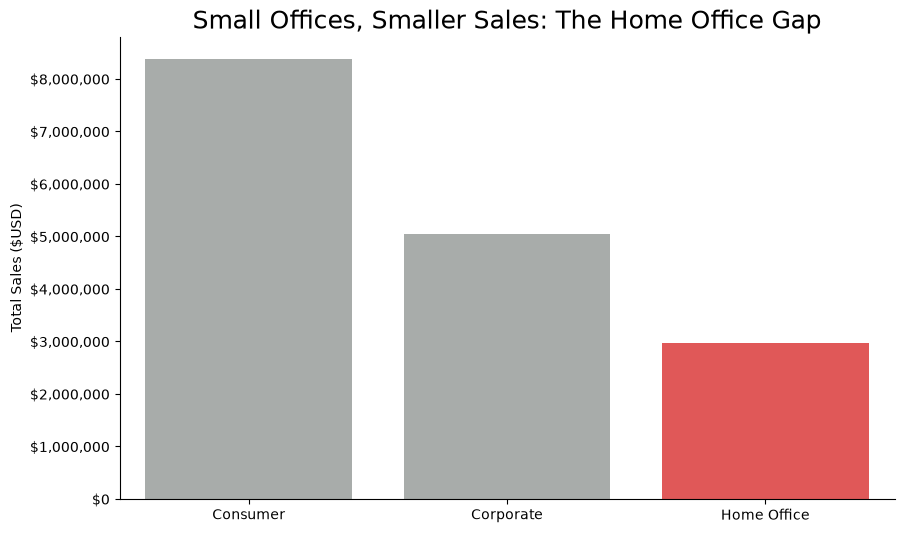

In [96]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


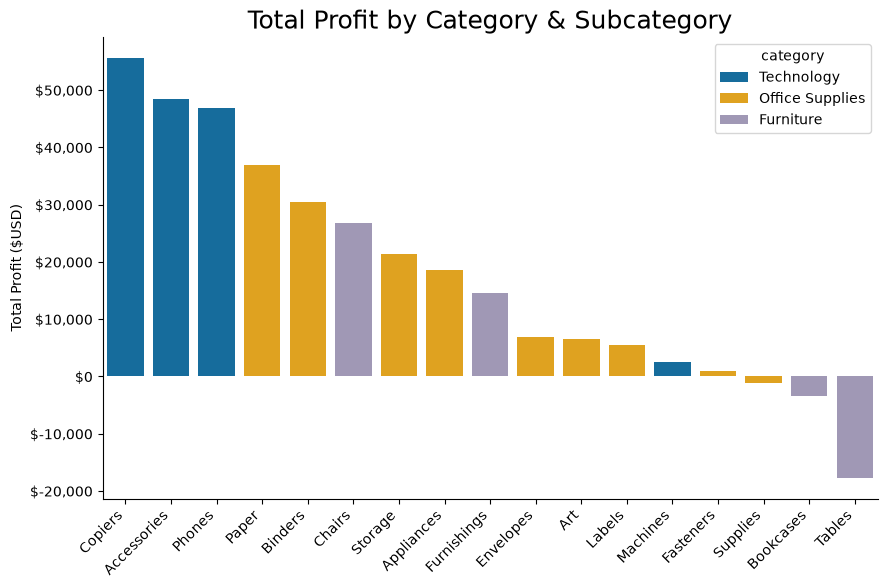

In [113]:
# visualization one code here

plt.figure(figsize=(10,6))
colors = {
    'Technology': '#0072b2',
    'Office Supplies': "#ffae00",
    'Furniture': "#9e93ba"
}
sns.barplot(result3, x='subcategory', y='total_profit', palette=colors, hue='category', legend=True, errorbar=None)
plt.title('Total Profit by Category & Subcategory',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Profit ($USD)')

plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()
plt.show()

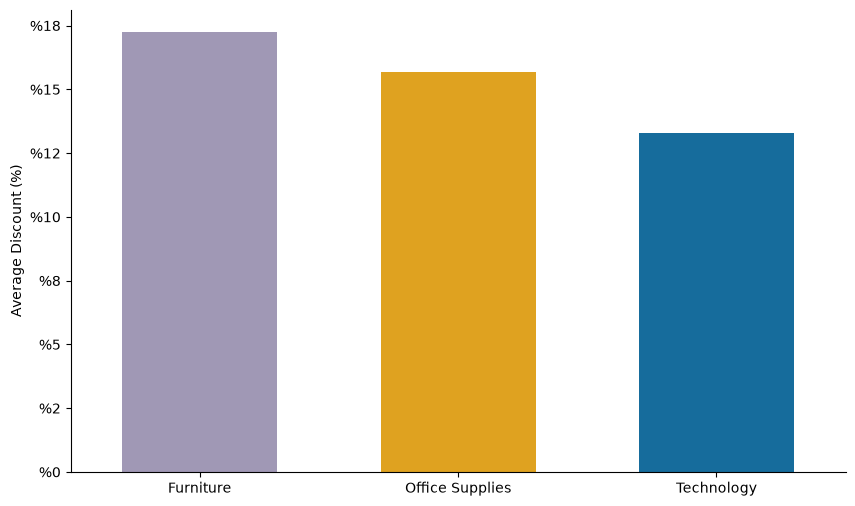

In [118]:
# visualization two code here

# example using result1
plt.figure(figsize=(10,6))
sns.barplot(result4, x='category', y='avg_discount', palette=colors, hue='category', legend=False, width=0.6)
plt.title('',fontsize=18)
plt.xlabel(None)
plt.ylabel('Average Discount (%)')

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'%{x:,.0f}'))

sns.despine()
plt.show()

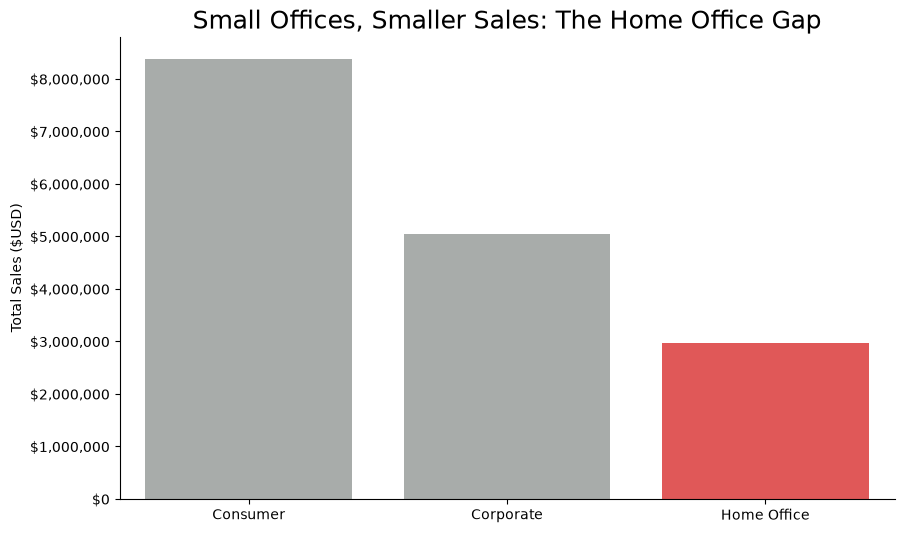

In [94]:
# visualization three code here

# example using result1
plt.figure(figsize=(10,6))
# colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()

# select
# p.product_name,
# count(od.order_id) as order_count
# from products p
# join order_details od on p.product_id = od.product_id
# group by p.product_name
# order by order_count desc
# limit 10;

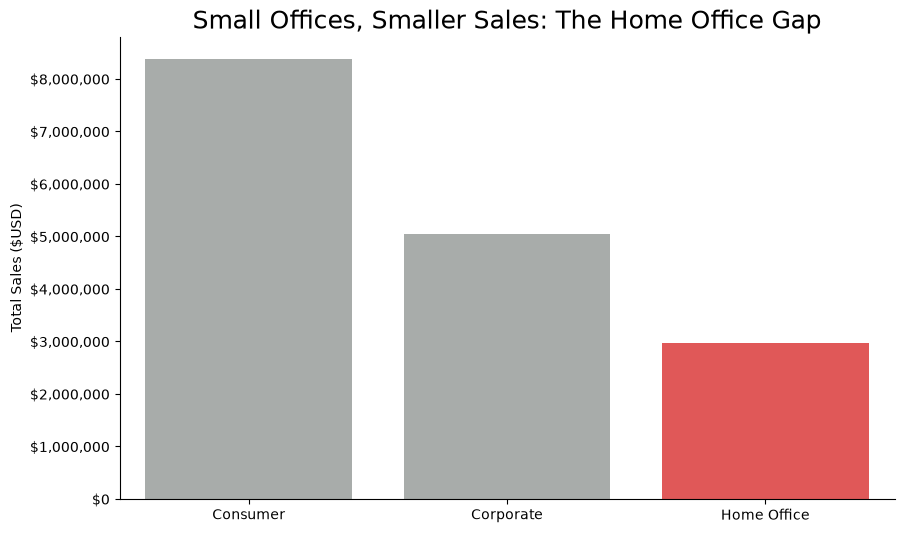

In [95]:
# visualization four code here

# example using result1
plt.figure(figsize=(10,6))
# colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()

# select
# p.category,
# sum(od.profit) / sum(od.sales) * 100 as profit_margin_percentage
# from products p
# join order_details od on p.product_id = od.product_id
# group by p.category
# order by profit_margin_percentage desc;